# Préparation des données – Sinistres automobiles chez ENSAssuRances

ROY Tao

2026-03-29

## Introduction
Ce document présente le processus complet de préparation et de nettoyage des données issues de la base Sinistre.

L’objectif de cette étape est de produire un jeu de données propre, cohérent et exploitable pour les analyses statistiques.

Les principales étapes de préparation sont :

- import et inspection initiale des données

- rennomage des colonnes

- nettoyage du contenu des variables qualitatives

- nettoyage du contenu des variables quantitatives

- Conversion des dates et tests de cohérences

- Détections et suppression des doublons

- analyse et traitement des valeurs manquantes

## 1. Chargement des librairies

Les bibliothèques suivantes sont utilisées pour la manipulation, la visualisation et le nettoyage des données :

In [28]:
import pandas as pd
from itables import show
from pandas.api.types import CategoricalDtype
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import missingno as msno

## 2. Importation des données

Les données sont importées depuis un fichier xlsx.

In [2]:
df_brut = pd.read_excel("data/Sinistre.xlsx")

On fait une inspection de la table chargée :

In [3]:
show(df_brut.head(100), 
     scrollX=True, 
     lengthMenu=[5, 10, 25, 50], 
     pageLength=5,
     classes="cell-border stripe")

Loading ITables v2.7.3 from the internet... (need help?)


In [4]:
print(f"Dimensions : {df_brut.shape}") # (Lignes, Colonnes)
print("-" * 30)
df_brut.info()
display(df_brut.head(3).T) # Aperçu transposé des 3 premières lignes

Dimensions : (72130, 8)
------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 72130 entries, 0 to 72129
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   idx_sin   72130 non-null  str    
 1   gar_sin   72130 non-null  str    
 2   surv_sin  72130 non-null  str    
 3   decl_sin  72130 non-null  str    
 4   clo_sin   33031 non-null  str    
 5   gest_sin  72130 non-null  str    
 6   mt_eval   72130 non-null  float64
 7   mt_regl   72130 non-null  float64
dtypes: float64(2), str(6)
memory usage: 4.4 MB


,0,1,2
idx_sin,S18-0043146,S18-0043146,S18-0043146
gar_sin,AssVHR,AssVHR,AssVHR
surv_sin,2018-12-08,2018-12-08,2018-12-08
decl_sin,2018-12-10,2018-12-10,2018-12-10
clo_sin,NaN,NaN,2019-08-05
gest_sin,2018-12-10,2018-12-31,2019-08-05
mt_eval,170.0,170.0,262.86
mt_regl,0.0,0.0,262.86


## 3. Rennomage des colonnes

Pour une utilisation plus simple de la donnée on va modifier le nom des colonnes comme ceci :

In [6]:
# Création du dictionnaire pour la table Sinistres (8 variables)
data_sinistres_complet = {
    "Nom d'origine": ["idx sin", "gar_sin", "surv sin", "decl sin", "clo sin", "gest_sin", "mt_eval", "mt_regl"],
    "Nouveau nom": [
        "id_sinistre", "type_garantie_sinistree", "date_survenance", "date_declaration", 
        "date_cloture", "date_gestion", "montant_evaluation", "montant_regle"
    ],
    "Type": ["texte", "texte", "texte", "texte", "texte", "texte", "decimal", "decimal"],
    "Description": [
        "Identifiant sinistre", 
        "Garantie sinistrée (Base, 0km, VHR)", 
        "Date de survenance", 
        "Date de déclaration", 
        "Date de clôture", 
        "Date de gestion", 
        "Montant évaluation", 
        "Montant réglé"
    ]
}

df_dico_sinistres = pd.DataFrame(data_sinistres_complet)

print("DICTIONNAIRE DES DONNÉES - SINISTRES")
display(df_dico_sinistres)

DICTIONNAIRE DES DONNÉES - SINISTRES


,Nom d'origine,Nouveau nom,Type,Description
0,idx sin,id_sinistre,texte,Identifiant sinistre
1,gar_sin,type_garantie_sinistree,texte,"Garantie sinistrée (Base, 0km, VHR)"
2,surv sin,date_survenance,texte,Date de survenance
3,decl sin,date_declaration,texte,Date de déclaration
4,clo sin,date_cloture,texte,Date de clôture
5,gest_sin,date_gestion,texte,Date de gestion
6,mt_eval,montant_evaluation,decimal,Montant évaluation
7,mt_regl,montant_regle,decimal,Montant réglé


In [1]:
# Dictionnaire de renommage pour la table Sinistres
mapping_sinistres = {
    "idx_sin": "id_sinistre",
    "gar_sin": "type_garantie_sinistree",
    "surv_sin": "date_survenance",
    "decl_sin": "date_declaration",
    "clo_sin": "date_cloture",
    "gest_sin": "date_gestion",
    "mt_eval": "montant_evaluation",
    "mt_regl": "montant_regle"
}

# Application du renommage (remplace df_sinistres par ton nom de variable)
df_prep = df_brut.rename(columns=mapping_sinistres)

NameError: name 'df_brut' is not defined

Nouveaux noms des 8 colonnes :

In [21]:
df_prep.columns

Index(['idx_sin', 'type_garantie_sinistree', 'date_survenance',
       'date_declaration', 'date_cloture', 'date_gestion',
       'montant_evaluation', 'montant_regle'],
      dtype='str')

## 4. Nettoyage du contenu des variables qualitatives

### 4.1 Normalisation de la colonne type_garantie_sinistree

In [12]:
df_prep['type_garantie_sinistree'].value_counts()

type_garantie_sinistree
AssBase    57685
Ass0km      8575
AssVHR      5870
Name: count, dtype: int64

On voit que l'on a bien nos 3 catégories cependant on va changer le nom des valeurs pour qu'elles soient plus explicite :

In [15]:
# Définition de la correspondance (Mapping)
# Basé sur ton dictionnaire : AssBase, Assokm, AssVHR
mapping_garanties = {
    "AssBase": "Assistance de base",
    "Ass0km": "Assistance 0 km",
    "AssVHR": "Véhicule de remplacement"
}

# Application de la transformation
df_prep['type_garantie_sinistree'] = df_prep['type_garantie_sinistree'].replace(mapping_garanties)

# Vérification du nouveau "table()"
print(df_prep['type_garantie_sinistree'].value_counts())

type_garantie_sinistree
Assistance de base          57685
Assistance 0 km              8575
Véhicule de remplacement     5870
Name: count, dtype: int64


## 5. Nettoyage du contenu des variables quantitatives

Maintenant nous allons travailler sur les problème de cohérence et de valeur abberante sur les variables numérique.

#### Voici les informations que nous avons concernant les différentes variables avant modification :

In [16]:
# Sélection de tes variables numériques spécifiques
cols_numeriques = [
    'montant_evaluation', 'montant_regle'
]

diagnostic_num = df_prep[cols_numeriques]

print("RÉSUMÉ STATISTIQUE DES VARIABLES NUMÉRIQUES")
display(diagnostic_num.describe().T)

# Vérification des valeurs manquantes
print("\nVALEURS MANQUANTES (NA) :")
print(diagnostic_num.isnull().sum())

RÉSUMÉ STATISTIQUE DES VARIABLES NUMÉRIQUES


,count,mean,std,min,25%,50%,75%,max
montant_evaluation,72130.0,254.449224,633.716936,-369.99,170.0,185.16,215.00,7429.16
montant_regle,72130.0,157.651405,661.917351,-369.99,0.0,0.00,191.34,7429.16



VALEURS MANQUANTES (NA) :
montant_evaluation    0
montant_regle         0
dtype: int64


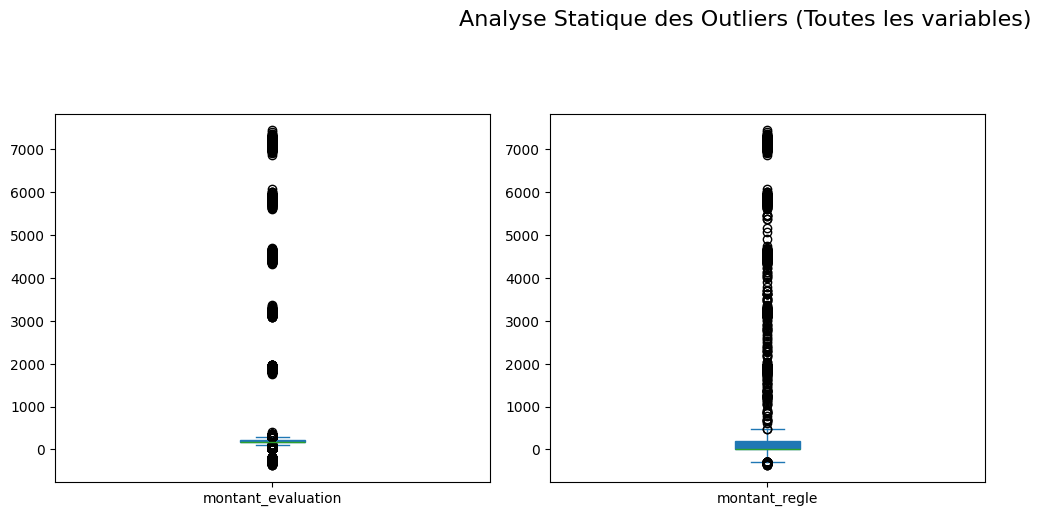

In [19]:
# Correction de la grille pour accueillir les 12 variables
df_prep[cols_numeriques].plot(
    kind='box', 
    subplots=True, 
    layout=(4, 3), # 4 lignes, 3 colonnes = 12 places
    figsize=(15, 18), # On augmente la hauteur (18) pour que ce soit lisible
    patch_artist=True
)

plt.suptitle("Analyse Statique des Outliers (Toutes les variables)", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajuste pour ne pas chevaucher le titre
plt.show()

Après une analyse des différentes variables il ne semble pas y avoir besoin d'apporter de modification.

## 6. Conversion des dates et tests de cohérence
### 6.1 Conversion des dates
Les dates des données ne sont pas de type date il faut donc les convertir.

In [22]:
# Conversion des colonnes en objets Datetime
cols_dates = ['date_survenance','date_declaration', 'date_cloture', 'date_gestion']

for col in cols_dates:
    df_prep[col] = pd.to_datetime(df_prep[col], dayfirst=True, errors='coerce')

# Diagnostic après conversion (équivalent de glimpse)
print("TYPES DES COLONNES APRÈS CONVERSION :")
print(df_prep[cols_dates].dtypes)

print("\nAPERÇU DES DONNÉES :")
display(df_prep[cols_dates].head())

TYPES DES COLONNES APRÈS CONVERSION :
date_survenance     datetime64[us]
date_declaration    datetime64[us]
date_cloture        datetime64[us]
date_gestion        datetime64[us]
dtype: object

APERÇU DES DONNÉES :


,date_survenance,date_declaration,date_cloture,date_gestion
0,2018-08-12,2018-10-12,NaT,2018-10-12
1,2018-08-12,2018-10-12,NaT,NaT
2,2018-08-12,2018-10-12,2019-05-08,2019-05-08
3,NaT,NaT,NaT,NaT
4,NaT,NaT,NaT,NaT


### 6.2 Tests de cohérence sur les dates
On vérifie si les dates sont cohérentes entre elles.

#### Voici les informations que l’on a sur les dates :

In [23]:
summary_dates = df_prep[cols_dates].describe().T

print("RÉSUMÉ STATISTIQUE DES DATES ET DÉLAIS :")
display(summary_dates)

RÉSUMÉ STATISTIQUE DES DATES ET DÉLAIS :


,count,mean,min,25%,50%,75%,max
date_survenance,28334,2021-07-28 19:49:32.852403,2018-01-09 00:00:00,2020-02-10 00:00:00,2021-09-09 00:00:00,2023-02-09 00:00:00,2023-12-12 00:00:00
date_declaration,28362,2021-08-04 06:56:53.412312,2018-01-09 00:00:00,2020-02-11 00:00:00,2021-10-01 00:00:00,2023-02-11 00:00:00,2023-12-12 00:00:00
date_cloture,12851,2021-09-13 04:15:42.370243,2018-01-10 00:00:00,2020-05-09 00:00:00,2021-11-03 00:00:00,2023-03-02 00:00:00,2023-12-12 00:00:00
date_gestion,25531,2021-09-05 06:16:12.088833,2018-01-09 00:00:00,2020-04-09 00:00:00,2021-11-01 00:00:00,2023-03-04 00:00:00,2023-12-12 00:00:00


Nous allons mettre en place plusieurs contrôle de cohérence et en cas de non respect nous allons remplacer les valeurs par des NA pour le moment.

Les contrôles sont :

- La déclaration ne peut pas être avant la survenance (le sinistre)
- On ne peut pas clôturer un dossier avant de l'avoir déclaré
- La gestion commence normalement à la déclaration ou après


In [25]:
print("\nNOMBRE DE VALEURS MANQUANTES (NA) AVANT CORRECTION :")
print(df_prep[['date_survenance', 'date_declaration', 'date_cloture', 'date_gestion']].isnull().sum())


NOMBRE DE VALEURS MANQUANTES (NA) AVANT CORRECTION :
date_survenance     43796
date_declaration    43781
date_cloture        60923
date_gestion        48252
dtype: int64


In [ ]:
# --- TEST 1 : Déclaration vs Survenance ---
# La déclaration ne peut pas être avant la survenance (le sinistre)
mask_decl_avant_surv = df_prep['date_declaration'] < df_prep['date_survenance']
print(f"Anomalies Déclaration < Survenance : {mask_decl_avant_surv.sum()}")

# --- TEST 2 : Clôture vs Déclaration ---
# On ne peut pas clôturer un dossier avant de l'avoir déclaré
mask_cloture_avant_decl = df_prep['date_cloture'] < df_prep['date_declaration']
print(f"Anomalies Clôture < Déclaration : {mask_cloture_avant_decl.sum()}")

# --- TEST 3 : Gestion vs Déclaration ---
# La gestion commence normalement à la déclaration ou après
mask_gestion_avant_decl = df_prep['date_gestion'] < df_prep['date_declaration']
print(f"Anomalies Gestion < Déclaration : {mask_gestion_avant_decl.sum()}")

# --- APPLICATION DES NA ---
# On remplace par NaT (Not a Time) les dates incohérentes
df_prep.loc[mask_decl_avant_surv, 'date_declaration'] = pd.NaT
df_prep.loc[mask_cloture_avant_decl, 'date_cloture'] = pd.NaT
df_prep.loc[mask_gestion_avant_decl, 'date_gestion'] = pd.NaT

# --- VÉRIFICATION FINALE ---
print("\nNOMBRE DE VALEURS MANQUANTES (NA) APRÈS CORRECTION :")
print(df_prep[['date_survenance', 'date_declaration', 'date_cloture', 'date_gestion']].isnull().sum())

Anomalies Déclaration < Survenance : 13
Anomalies Clôture < Déclaration : 1644
Anomalies Gestion < Déclaration : 1653

NOMBRE DE VALEURS MANQUANTES (NA) APRÈS CORRECTION :
date_survenance     43796
date_declaration    43781
date_cloture        60923
date_gestion        48252
dtype: int64


## 7. Détection et suppression des doublons
Certaines lignes peuvent être strictement identiques suite à des erreurs d’import ou de saisie.

In [26]:
df_doublons = df_prep[df_prep.duplicated(keep=False)]
print(f"Nombre de lignes concernées par des doublons : {len(df_doublons)}")

# 2. Comptage avant nettoyage
n_avant = len(df_prep)
print(f"Nombre total de lignes avant nettoyage : {n_avant}")

# 3. Suppression des doublons 
df_prep = df_prep.drop_duplicates()

# 4. Comptage après nettoyage
n_apres = len(df_prep)
print(f"Nombre total de lignes après nettoyage : {n_apres}")
print(f"Nombre de lignes uniques supprimées : {n_avant - n_apres}")

Nombre de lignes concernées par des doublons : 9324
Nombre total de lignes avant nettoyage : 72130
Nombre total de lignes après nettoyage : 67452
Nombre de lignes uniques supprimées : 4678


## 8. Analyse des données manquantes
Les valeurs manquantes peuvent provenir :

- d’erreurs de mesure

- d’informations non disponibles

- d’erreurs de saisie

Une analyse détaillée est donc nécessaire.

### 8.1 Résumé des valeurs manquantes
Voici les valeurs manquantes et la proportion quelle représente :

In [31]:
# 1. Calcul du nombre de NA par variable
n_miss = df_prep.isnull().sum()

# 2. Calcul du pourcentage de NA
pct_miss = (n_miss / len(df_prep)) * 100

# 3. Création du tableau de synthèse (équivalent miss_var_summary)
miss_var_summary = pd.DataFrame({
    'variable': n_miss.index,
    'n_miss': n_miss.values,
    'pct_miss': pct_miss.values
})

# 4. Tri par ordre décroissant de manquants
miss_var_summary = miss_var_summary.sort_values(by='n_miss', ascending=False).reset_index(drop=True)

print("RÉSUMÉ DES VARIABLES MANQUANTES :")
display(miss_var_summary)

RÉSUMÉ DES VARIABLES MANQUANTES :


,variable,n_miss,pct_miss
0,date_cloture,56245,83.385222
1,date_gestion,43574,64.600012
2,date_survenance,39689,58.840361
3,date_declaration,39126,58.005693
4,idx_sin,0,0.000000
5,type_garantie_sinistree,0,0.000000
6,montant_evaluation,0,0.000000
7,montant_regle,0,0.000000


On laissera les date pour lesquels il manque la donnée tel quel car on ne pourra pas procédé par imputation et les supprimé reviendrais à supprimer trop de ligne. De plus le reste des informations peut être utile.

Ainsi, nous n'avons aucun travail d'imputation ou de suppression de ligne à faire car il ne manque aucune valeurs dans les variable qui ne sont pas de type date.

## Conclusion
Désormais le jeu de données obtenu est cohérent, propre et prêt pour l’analyse exploratoire et la modélisation statistique.

Dernière information sur la table nettoyé :

In [32]:
# On définit le DataFrame final
df_final = df_prep.copy()

# Nombre de lignes et colonnes (équivalent ncol et nrow)
print(f"Nombre de colonnes : {df_final.shape[1]}")
print(f"Nombre de lignes : {df_final.shape[0]}")

print("-" * 30)

# Équivalent de glimpse() : donne le type, les non-nuls et un aperçu
print("DERNIÈRE INFORMATION SUR LA TABLE NETTOYÉE :")
df_final.info()

# Aperçu des premières lignes
display(df_final.head())

Nombre de colonnes : 8
Nombre de lignes : 67452
------------------------------
DERNIÈRE INFORMATION SUR LA TABLE NETTOYÉE :
<class 'pandas.DataFrame'>
Index: 67452 entries, 0 to 72129
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   idx_sin                  67452 non-null  str           
 1   type_garantie_sinistree  67452 non-null  str           
 2   date_survenance          27763 non-null  datetime64[us]
 3   date_declaration         28326 non-null  datetime64[us]
 4   date_cloture             11207 non-null  datetime64[us]
 5   date_gestion             23878 non-null  datetime64[us]
 6   montant_evaluation       67452 non-null  float64       
 7   montant_regle            67452 non-null  float64       
dtypes: datetime64[us](4), float64(2), str(2)
memory usage: 4.6 MB


,idx_sin,type_garantie_sinistree,date_survenance,date_declaration,date_cloture,date_gestion,montant_evaluation,montant_regle
0,S18-0043146,AssVHR,2018-08-12,2018-10-12,NaT,2018-10-12,170.00,0.00
1,S18-0043146,AssVHR,2018-08-12,2018-10-12,NaT,NaT,170.00,0.00
2,S18-0043146,AssVHR,2018-08-12,2018-10-12,2019-05-08,2019-05-08,262.86,262.86
3,S18-0057961,Ass0km,NaT,NaT,NaT,NaT,150.00,0.00
5,S18-0057961,Ass0km,NaT,NaT,NaT,NaT,229.51,229.51


In [33]:
# Résumé pour les variables numériques
print("RÉSUMÉ NUMÉRIQUE :")
display(df_final.describe().T)

# Résumé pour les variables catégorielles (Factor/Object)
print("\nRÉSUMÉ CATÉGORIEL :")
display(df_final.describe(include=['object', 'category']).T)

RÉSUMÉ NUMÉRIQUE :


,count,mean,min,25%,50%,75%,max,std
date_survenance,27763,2021-07-29 00:13:01.125959,2018-01-09 00:00:00,2020-02-10 00:00:00,2021-09-09 00:00:00,2023-02-09 00:00:00,2023-12-12 00:00:00,NaN
date_declaration,28326,2021-08-04 21:48:56.581232,2018-01-09 00:00:00,2020-02-11 00:00:00,2021-10-02 00:00:00,2023-02-11 00:00:00,2023-12-12 00:00:00,NaN
date_cloture,11207,2021-09-20 01:03:13.057910,2018-01-10 00:00:00,2020-05-12 00:00:00,2021-11-04 00:00:00,2023-03-05 00:00:00,2023-12-12 00:00:00,NaN
date_gestion,23878,2021-09-07 20:46:39.430438,2018-01-09 00:00:00,2020-04-09 00:00:00,2021-11-02 00:00:00,2023-03-06 00:00:00,2023-12-12 00:00:00,NaN
montant_evaluation,67452.0,259.09065,-369.99,170.0,186.7,215.0,7429.16,655.043321
montant_regle,67452.0,168.585006,-369.99,0.0,0.0,195.28,7429.16,683.13814



RÉSUMÉ CATÉGORIEL :


C:\Users\taoro\AppData\Local\Temp\ipykernel_94180\878102804.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df_final.describe(include=['object', 'category']).T)


,count,unique,top,freq
idx_sin,67452,35214,S19-0082730,4
type_garantie_sinistree,67452,3,AssBase,54340


#### Export des données nettoyées
On export les données nettoyé en temps que csv “Sinistre_clean.csv” dans le dossier data

In [34]:
# Exportation 
df_final.to_csv("data/Sinistre_clean.csv", index=False, sep=",", encoding='utf-8')